/home/dszczeci/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Files already downloaded and verified
Files already downloaded and verified


/home/dszczeci/.local/lib/python3.11/site-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 2 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Extracting supervised features...
Extracting SSL-pretrained+finetuned features...
Running UMAP for supervised-only features...


/localscratch/dszczeci.53323262.0/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


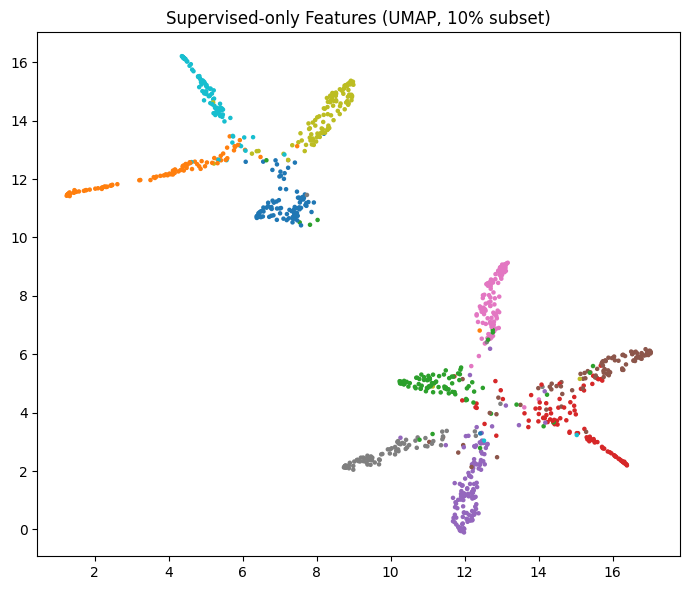

Running UMAP for SSL-pretrained + finetuned features...


NameError: name 'X_ssl_sub' is not defined

In [1]:
import torch
import numpy as np
import umap
import matplotlib.pyplot as plt

from ssl_cifar_experiment import (
    ResNet18Small, get_dataloaders, extract_features, load_encoder_into_classifier
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# -----------------------------
# Paths to your saved models
# -----------------------------
SUPERVISED_CKPT = "results_cifar10/baseline_cifar10_supE-10_noise-0.6_s-1/baseline_cifar10_noise0.60_freeze0.pt" 
SUPERVISED_CKPT = "results_cifar10/baseline_cifar10_supE-10_noise-0.0_s-1/baseline_cifar10_noise0.00_freeze0.pt"
SUPERVISED_CKPT = "results_cifar10/baseline-imagenet_cifar10_supE-10_noise-0.0_s-1/baseline_cifar10_noise0.00_freeze0.pt"
SSL_ENCODER_PATH = "pretrained_encoders/simclr_cifar10_e50_s1.pth"
SSL_FINETUNE_CKPT = "results_cifar10/simclr_cifar10_preE-50_supE-10_noise-0.6_s-1/ft_cifar10_noise0.60_freeze0.pt" 
SSL_FINETUNE_CKPT = "results_cifar10/simclr_cifar10_preE-50_supE-10_noise-0.0_s-1/ft_cifar10_noise0.00_freeze0.pt"


DATASET = "cifar10"
NOISE = 0.0
BATCH = 256
SUBSET_FRACTION = .10  # use 10% of the data


def load_supervised_model():
    model = ResNet18Small(num_classes=10).to(DEVICE)
    model.load_state_dict(torch.load(SUPERVISED_CKPT, map_location=DEVICE))
    model.eval()
    return model


def load_ssl_finetuned_model():
    model = ResNet18Small(num_classes=10).to(DEVICE)
    load_encoder_into_classifier(SSL_ENCODER_PATH, model)
    model.load_state_dict(torch.load(SSL_FINETUNE_CKPT, map_location=DEVICE), strict=False)
    model.eval()
    return model



# --- Load data (test set for visualization) ---
_, test_loader, test_ds, _ = get_dataloaders(
    dataset=DATASET,
    batch_size=BATCH,
    noise_rate=NOISE,
    workers=2,
    seed=1
)

# --- Load models ---
sup = load_supervised_model()
ssl = load_ssl_finetuned_model()

# --- Extract embedding features ---
print("Extracting supervised features...")
X_sup, y = extract_features(sup, test_loader, DEVICE)

print("Extracting SSL-pretrained+finetuned features...")
#X_ssl, _ = extract_features(ssl, test_loader, DEVICE)

# Ensure numpy arrays
X_sup = np.asarray(X_sup)
X_ssl = np.asarray(X_ssl)
y = np.asarray(y)

# --- Subsample 10% of the data (same indices for both models) ---
n_samples = y.shape[0]
n_subset = max(1, int(SUBSET_FRACTION * n_samples))
rng = np.random.RandomState(1)
subset_idx = rng.choice(n_samples, size=n_subset, replace=False)

X_sup_sub = X_sup[subset_idx]
X_ssl_sub = X_ssl[subset_idx]
y_sub = y[subset_idx]

# -----------------------------
# UMAP for supervised-only features
# -----------------------------
print("Running UMAP for supervised-only features...")
reducer_sup = umap.UMAP(n_components=2, random_state=1)
Z_sup = reducer_sup.fit_transform(X_sup_sub)

plt.figure(figsize=(7, 6))
plt.scatter(Z_sup[:, 0], Z_sup[:, 1], c=y_sub, cmap="tab10", s=5)
plt.title("Supervised-only Features (UMAP, 10% subset)")
plt.tight_layout()
plt.savefig("umap_supervised.png", dpi=300)
plt.show()

# -----------------------------
# UMAP for SSL-pretrained + finetuned features
# -----------------------------
print("Running UMAP for SSL-pretrained + finetuned features...")
reducer_ssl = umap.UMAP(n_components=2, random_state=1)
Z_ssl = reducer_ssl.fit_transform(X_ssl_sub)

plt.figure(figsize=(7, 6))
plt.scatter(Z_ssl[:, 0], Z_ssl[:, 1], c=y_sub, cmap="tab10", s=5)
plt.title("SSL Pretrained → Finetuned Features (UMAP, 10% subset)")
plt.tight_layout()
plt.savefig("umap_ssl_finetuned.png", dpi=300)
plt.show()





In [ ]:
plt.figure(figsize=(7, 6))
plt.scatter(Z_sup[:, 0], Z_sup[:, 1], c=y_sub, cmap="tab10", s=5)
plt.xlim(-7,11)
plt.xticks([])
plt.yticks([])
plt.title("Supervised-only Imagenet-init UMAP Features")
plt.tight_layout()
plt.savefig("umap_supervised.png", dpi=300)
plt.show()


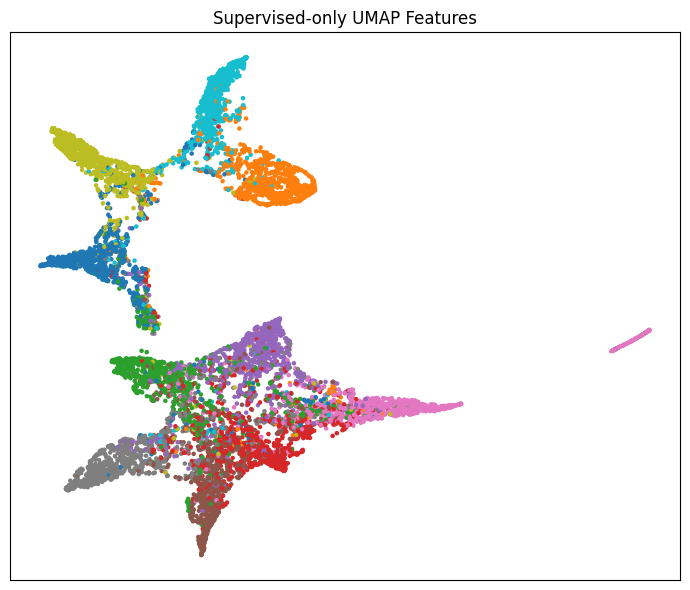

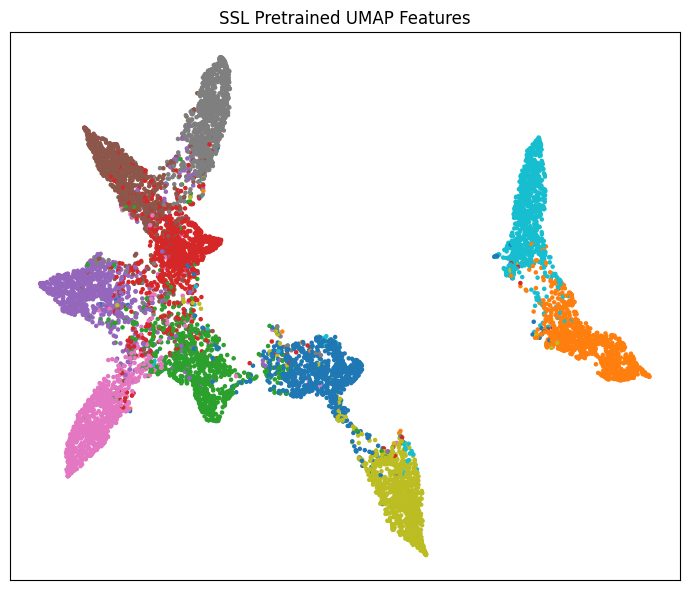

In [15]:
plt.figure(figsize=(7, 6))
plt.scatter(Z_sup[:, 0], Z_sup[:, 1], c=y_sub, cmap="tab10", s=5)
plt.xticks([])
plt.yticks([])
plt.title("Supervised-only UMAP Features")
plt.tight_layout()
plt.savefig("umap_supervised.png", dpi=300)
plt.show()

# -----------------------------
# UMAP for SSL-pretrained + finetuned features
# -----------------------------

plt.figure(figsize=(7, 6))
plt.scatter(Z_ssl[:, 0], Z_ssl[:, 1], c=y_sub, cmap="tab10", s=5)
plt.xticks([])
plt.yticks([])
plt.title("SSL Pretrained UMAP Features")
plt.tight_layout()
plt.savefig("umap_ssl_finetuned.png", dpi=300)
plt.show()

Files already downloaded and verified
Files already downloaded and verified


/home/dszczeci/.local/lib/python3.11/site-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 2 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Loaded encoder from pretrained_encoders/simclr_cifar10_e50_s1.pth.
Extracting UNTRAINED features...
Extracting SSL-INITIALIZED features...
Running UMAP for UNTRAINED features...


/localscratch/dszczeci.53323262.0/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


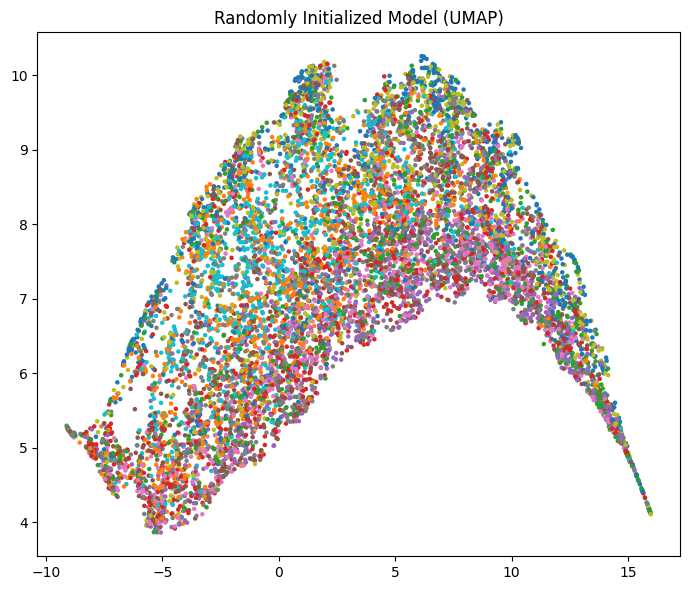

Running UMAP for SSL-INITIALIZED features...


/localscratch/dszczeci.53323262.0/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


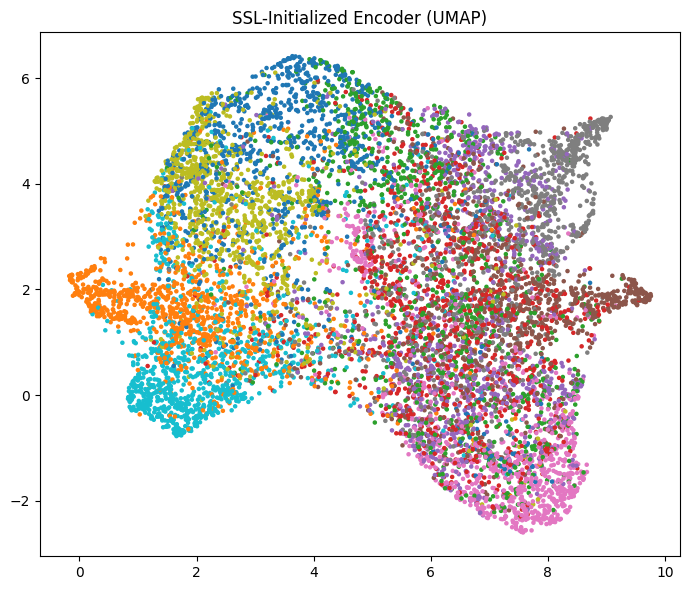

'\nX_joint = np.vstack([X_untrained_sub, X_ssl_init_sub])\nlabels_model = np.array([0]*len(X_untrained_sub) + [1]*len(X_ssl_init_sub))\n\nreducer_joint = umap.UMAP(n_components=2, random_state=1)\nZ_joint = reducer_joint.fit_transform(X_joint)\n\nZ_untrained_joint = Z_joint[:len(X_untrained_sub)]\nZ_ssl_joint = Z_joint[len(X_untrained_sub):]\n\nplt.figure(figsize=(7, 6))\nplt.scatter(Z_untrained_joint[:, 0], Z_untrained_joint[:, 1], c=y_sub, cmap="tab10", s=5, alpha=0.6, label="Untrained")\nplt.scatter(Z_ssl_joint[:, 0], Z_ssl_joint[:, 1], c=y_sub, cmap="tab10", s=5, marker="x", alpha=0.6, label="SSL init")\nplt.title("Untrained vs SSL-Initialized in Same UMAP Space")\nplt.legend()\nplt.tight_layout()\nplt.savefig("umap_joint_untrained_vs_ssl.png", dpi=300)\nplt.show()\n'

In [2]:
import torch
import numpy as np
import umap
import matplotlib.pyplot as plt

from ssl_cifar_experiment import (
    ResNet18Small, get_dataloaders, extract_features, load_encoder_into_classifier
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# -----------------------------
# Paths
# -----------------------------
SSL_ENCODER_PATH = "pretrained_encoders/simclr_cifar10_e50_s1.pth"

DATASET = "cifar10"
NOISE = 0.0
BATCH = 256
SUBSET_FRACTION = 1.0  # e.g. 0.1 for 10% of test set

# -----------------------------
# Model loaders
# -----------------------------
def load_untrained_model():
    """
    Randomly initialized classifier (same architecture, no training).
    """
    model = ResNet18Small(num_classes=10).to(DEVICE)
    model.eval()
    return model


def load_ssl_initialized_model():
    """
    Same classifier architecture, but encoder initialized from SSL weights.
    No supervised fine-tuning.
    """
    model = ResNet18Small(num_classes=10).to(DEVICE)
    load_encoder_into_classifier(SSL_ENCODER_PATH, model)  # <-- SSL init
    model.eval()
    return model


# --- Load data (test set for visualization) ---
_, test_loader, test_ds, _ = get_dataloaders(
    dataset=DATASET,
    batch_size=BATCH,
    noise_rate=NOISE,
    workers=2,
    seed=1
)

# --- Load models ---
untrained = load_untrained_model()
ssl_init = load_ssl_initialized_model()

# --- Extract embedding features ---
print("Extracting UNTRAINED features...")
X_untrained, y = extract_features(untrained, test_loader, DEVICE)

print("Extracting SSL-INITIALIZED features...")
X_ssl_init, _ = extract_features(ssl_init, test_loader, DEVICE)

# Ensure numpy arrays
X_untrained = np.asarray(X_untrained)
X_ssl_init = np.asarray(X_ssl_init)
y = np.asarray(y)

# --- Subsample same indices for both models ---
n_samples = y.shape[0]
n_subset = max(1, int(SUBSET_FRACTION * n_samples))
rng = np.random.RandomState(1)
subset_idx = rng.choice(n_samples, size=n_subset, replace=False)

X_untrained_sub = X_untrained[subset_idx]
X_ssl_init_sub = X_ssl_init[subset_idx]
y_sub = y[subset_idx]

# -----------------------------
# Option 1: Separate UMAPs (simpler)
# -----------------------------
print("Running UMAP for UNTRAINED features...")
reducer_untrained = umap.UMAP(n_components=2, random_state=1)
Z_untrained = reducer_untrained.fit_transform(X_untrained_sub)

plt.figure(figsize=(7, 6))
plt.scatter(Z_untrained[:, 0], Z_untrained[:, 1], c=y_sub, cmap="tab10", s=5)
plt.title("Randomly Initialized Model (UMAP)")
plt.tight_layout()
plt.savefig("umap_untrained.png", dpi=300)
plt.show()

print("Running UMAP for SSL-INITIALIZED features...")
reducer_ssl = umap.UMAP(n_components=2, random_state=1)
Z_ssl = reducer_ssl.fit_transform(X_ssl_init_sub)

plt.figure(figsize=(7, 6))
plt.scatter(Z_ssl[:, 0], Z_ssl[:, 1], c=y_sub, cmap="tab10", s=5)
plt.title("SSL-Initialized Encoder (UMAP)")
plt.tight_layout()
plt.savefig("umap_ssl_init.png", dpi=300)
plt.show()

# -----------------------------
# Option 2 (better comparison): Joint UMAP space
# -----------------------------
# If you want both clouds in the SAME UMAP space:
"""
X_joint = np.vstack([X_untrained_sub, X_ssl_init_sub])
labels_model = np.array([0]*len(X_untrained_sub) + [1]*len(X_ssl_init_sub))

reducer_joint = umap.UMAP(n_components=2, random_state=1)
Z_joint = reducer_joint.fit_transform(X_joint)

Z_untrained_joint = Z_joint[:len(X_untrained_sub)]
Z_ssl_joint = Z_joint[len(X_untrained_sub):]

plt.figure(figsize=(7, 6))
plt.scatter(Z_untrained_joint[:, 0], Z_untrained_joint[:, 1], c=y_sub, cmap="tab10", s=5, alpha=0.6, label="Untrained")
plt.scatter(Z_ssl_joint[:, 0], Z_ssl_joint[:, 1], c=y_sub, cmap="tab10", s=5, marker="x", alpha=0.6, label="SSL init")
plt.title("Untrained vs SSL-Initialized in Same UMAP Space")
plt.legend()
plt.tight_layout()
plt.savefig("umap_joint_untrained_vs_ssl.png", dpi=300)
plt.show()
"""
